# Capacitated Power Dominating Set

### Parameters:
TIMEOUT = 900 (seconds)</br>
NRUNS = 5</br>

## Import packages

In [1]:
from tools import *

## Read data

In [2]:
df_stats1 = pd.read_csv("stats1.csv", index_col=0)
df_stats2 = pd.read_csv("stats2.csv", index_col=0)
df_stats3 = pd.read_csv("stats3.csv", index_col=0)
df_stats4 = pd.read_csv("stats4.csv", index_col=0)

df = pd.concat([df_stats1, df_stats2, df_stats3, df_stats4], ignore_index=True)

Clean the data.

In [3]:
# Change column name "omega" to "k"
df = df.rename(columns={"omega": "k"})

# Handle instances where no solution was found
df.gap = df.apply(lambda row: (row.vertices - row.lower_bound) / (row.vertices + 10e-6) if row.upper_bound == -1.0 else row.gap, axis=1)
df.upper_bound = df.apply(lambda row: row.vertices if row.upper_bound == -1.0 else row.upper_bound, axis=1)

# Handle instance with timeout
timeout = 900000000 # 900000000 microseconds = 900 seconds = 15 minutes
df.loc[df.result == "Timeout", "t_solver"] = timeout

# Transform microseconds to seconds
timeout = int(timeout / 1000000)
df.t_solver = df.t_solver / 1000000
df.t_callback = df.t_callback / 1000000

# Clean instance names
df.instance = df.instance.apply(lambda x: x.split("/")[-1])
df.instance = df.instance.apply(lambda x: x.split(".")[0])
df.instance = df.instance.apply(lambda x: x.removeprefix("case_"))
df.instance = df.instance.apply(lambda x: x.removeprefix("case"))

# Remove instances with less than 200 vertices
df = df[(df.vertices >= 200)]

# Rename solvers
solver_map = {"brimkov": 'BRI-IP',
              "brimkov-outp": 'BRI-IP-OutP',
              "jovanovic": 'JOV-IP',
              "forts": 'FORT-IP',
              "efpss": "EFPS-IP",
              "efpss-inp": "EFPS-IP-InP",
              "efpss-outp": "EFPS-IP-OutP",
              "efpss-inp-outp": "EFPS-IP-InP-OutP",
              "efpss-outp-init": "EFPS-IP-OutP-Init",
              "fpss": "FPS-IP"
              }
df.solver = df.solver.apply(lambda x: solver_map[x])

# Sort values
df = df.sort_values(["vertices", "solver", "k", "run"], ignore_index=True)
df

,solver,instance,vertices,edges,propagating_vertices,k,variables,constraints,run,lower_bound,upper_bound,gap,result,nodes,t_solver,callbacks,t_callback,lazy_constraints
0,BRI-IP,illinois200,200,245,44,0,1074,1304,0,156.0,156,0.0,Optimal,1,0.061905,0,0.0,0
1,BRI-IP,illinois200,200,245,44,0,1074,1304,1,156.0,156,0.0,Optimal,1,0.058577,0,0.0,0
2,BRI-IP,illinois200,200,245,44,0,1074,1304,2,156.0,156,0.0,Optimal,1,0.058100,0,0.0,0
3,BRI-IP,illinois200,200,245,44,0,1074,1304,3,156.0,156,0.0,Optimal,1,0.058234,0,0.0,0
4,BRI-IP,illinois200,200,245,44,0,1074,1304,4,156.0,156,0.0,Optimal,1,0.058140,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20695,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,0,2721.0,2721,0.0,Optimal,1810,114.208638,0,0.0,0
20696,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,1,2721.0,2721,0.0,Optimal,1810,113.605977,0,0.0,0
20697,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,2,2721.0,2721,0.0,Optimal,1810,113.291765,0,0.0,0
20698,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,3,2721.0,2721,0.0,Optimal,1810,113.382452,0,0.0,0


In [4]:
# Set colors for the models
colors = {
    "BRI-IP": "#1da5c7",
    "BRI-IP-OutP": "#0E6570",
    "JOV-IP": "#2ca02c",
    "FORT-IP": "#8a48c7",
    "FPS-IP": "#1f77b4",
    "EFPS-IP": "#ff7f0e",
    "EFPS-IP-InP": "#9467bd",
    "EFPS-IP-OutP": "#189e18",
    "EFPS-IP-InP-OutP": "#ca4fba",
    "EFPS-IP-OutP-Init": "#d62728",
    "tie": "#7f7f7f",
}

# Set markers for the models
markers = {
    "BRI-IP": "s",
    "BRI-IP-OutP": "D",
    "JOV-IP": "^",
    "FORT-IP": "P",
    "FPS-IP": "s",
    "EFPS-IP": "o",
    "EFPS-IP-InP": "s",
    "EFPS-IP-OutP": "D",
    "EFPS-IP-InP-OutP": "P",
    "EFPS-IP-OutP-Init": "o",
    "tie": "X",
}

## Check solutions

In [5]:
def opt_val(serie):
    if serie.result == "Optimal":
        return serie.upper_bound
    else:
        return float("nan")

df["opt_val"] = df[["result", "upper_bound"]].apply(opt_val, axis=1)

In [6]:
for instance in df.instance.unique():
    df1 = df[df.instance == instance]
    for l in df1.k.unique():
        df2 = df1[df1.k == l]
        lb = df2.lower_bound.max()
        ub = df2.upper_bound.min()
        if (isnan(df2.opt_val.min())):
            # Check lower and upper bounds
            assert(lb <= ub)            
        else:
            #print(instance, omega, df2.opt_val.min(), df2.opt_val.max())
            assert(df2.opt_val.min() == df2.opt_val.max())
            val = df2.opt_val.max()
            # Check lower and upper bounds
            assert(lb <= val)
            assert(val <= ub)
print("Checks passed :)")

Checks passed :)


## Compute $k^*$

$k^*$ is the minumum $k$ such that the optimal value of CPDS is equal to the optimal value of PDS.

In [7]:
df4 = df.sort_values(["vertices", "instance", "opt_val", "k"], ignore_index=True).groupby("instance").head(1)
k_star = dict(zip(df4.instance, df4.k))
print(k_star)

{'illinois200': 8, '300': 8, 'south_carolina500': 9, '1354pegase': 8, '1888rte': 8, '1951rte': 11, 'Texas': 12, 'GB2224': 9, '2383wp': 6, '2736sp': 6, '2737sop': 6, '2746wop': 7, '2746wp': 7, '2848rte': 9, '2868rte': 9, '2869pegase': 9, '3012wp': 7, '3120sp': 6, '3375wp': 7, '6468rte': 10, '6470rte': 10, '6495rte': 10, '6515rte': 10, '9241pegase': 9, 'Western': 11, '13659pegase': 24}


In [8]:
def classify(x):
    if x.k/x.k_star <= 1/3:
        return "low"
    elif x.k/x.k_star <= 2/3:
        return "medium"
    else:
        return "high"

df["k_star"] = df["instance"].apply(lambda x: k_star[x])
df["k_coef"] = df["k"] / df["k_star"]
df["k_class"] = df[["k","k_star"]].apply(classify, axis=1)

Remove instances with $k$ greater than $k^*$.

In [9]:
df["k_star"] = df["instance"].apply(lambda x: k_star[x])
df = df[df.k <= df.k_star]

## Summary per model

In [10]:
def count_opt(serie):
    return serie[serie == "Optimal"].count()
def gap_feas(serie):
    return serie[serie > 0].mean()
def time_all(serie):
    return serie.mean()

df3 = df.groupby(["solver"], as_index=False).agg(
    variables=("variables", "mean"),
    constraints=("constraints", "mean"),
    lazies=("lazy_constraints", "mean"),
    optimality = ("result", count_opt),
    time_all = ("t_solver", time_all),
    time_lazy = ("t_callback", "mean"),
    gap_feas = ("gap", gap_feas),
)
df3["variables"] = df3["variables"] / 1000
df3["constraints"] = df3["constraints"] / 1000
df3["optimality"] = df3["optimality"] * 100 / (len(df) / len(df.solver.unique()))
df3["gap_feas"] = df3["gap_feas"] * 100
columns = [("Model",""), ("#Variables (x10³)",""), ("#Constraints","Initial (x10³)"), ("#Constraints","Lazy"),
           ("Optimality (%)",""), ("Time (s)","Total"), ("Time (s)","Lazy"), ("Gap (%)","")]
df3.columns = pd.MultiIndex.from_tuples(columns)
df3 = df3.round({
    ("#Variables (x10³)",""): 1, 
    ("#Constraints","Initial (x10³)"): 1, 
    ("Optimality (%)",""): 1,
    ("Time (s)","Total"): 1,
    ("Time (s)","Lazy"): 3,
    ("Gap (%)",""): 3,
})
df3[("#Constraints","Lazy")] = df3[("#Constraints","Lazy")].round(0).astype(int)
df3 = df3.replace(0, "--")
df3

Model #Variables (x10³)   #Constraints        Optimality (%)  \
                                       Initial (x10³)   Lazy                  
0             BRI-IP              17.8           26.5     --           92.4   
1        BRI-IP-OutP              17.8           28.0     --           93.9   
2            EFPS-IP              13.2            5.6   5185           90.9   
3        EFPS-IP-InP              13.2            8.5   3207           90.5   
4   EFPS-IP-InP-OutP              13.2           10.0    128           94.0   
5       EFPS-IP-OutP              13.2            7.1    134           94.1   
6  EFPS-IP-OutP-Init              13.2           15.8     17           94.4   
7            FORT-IP               8.5            1.0  22096           53.5   
8             FPS-IP              13.2            5.6   5461           90.2   
9             JOV-IP              17.8           51.4     --           92.0   

  Time (s)        Gap (%)  
     Total   Lazy          
0    103.3     --   0.242  
1     82.9     --   0.206  
2     99.9  0.154   0.189  
3    104.3  0.159   0.208  
4     63.2  0.035   0.185  
5     61.0  0.035   0.169  
6     60.8  0.021   0.184  
7    431.7  1.002  27.809  
8    109.9   0.17   0.783  
9    141.5     --   0.224

## Summary per instance and solver

In [11]:
def time_opt(serie):
    return serie[serie < timeout].mean()

df2 = df.groupby(["instance","vertices","edges","propagating_vertices","solver",
                  "k","variables","constraints"], as_index=False).agg(
    result = ("result", count_opt),
    time_opt = ("t_solver", time_opt),
    gap_feas = ("gap", gap_feas),
    # time_all = ("t_solver", time_all),
    upper_bound = ("upper_bound", "mean"),
    lower_bound = ("lower_bound", "mean"),
    # k_star = ("k_star", "min"),
    # lazy_time = ("t_callback", "mean"),
    # lazy_added = ("lazy_constraints", "mean"),
)
df2 = df2.sort_values(["vertices", "instance", "solver", "k"])
df2

,instance,vertices,edges,propagating_vertices,solver,k,variables,constraints,result,time_opt,gap_feas,upper_bound,lower_bound
2430,illinois200,200,245,44,BRI-IP,0,1074,1304,5,0.058991,NaN,156.0,156.0
2431,illinois200,200,245,44,BRI-IP,1,1002,1232,5,0.080285,NaN,97.0,97.0
2432,illinois200,200,245,44,BRI-IP,2,892,1177,5,0.109061,NaN,68.0,68.0
2433,illinois200,200,245,44,BRI-IP,3,799,1146,5,0.175205,NaN,57.0,57.0
2434,illinois200,200,245,44,BRI-IP,4,719,1126,5,0.112723,NaN,50.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,13659pegase,13659,18625,4024,JOV-IP,20,41547,153201,5,152.756328,NaN,2729.0,2729.0
336,13659pegase,13659,18625,4024,JOV-IP,21,41421,153195,5,150.323199,NaN,2726.0,2726.0
337,13659pegase,13659,18625,4024,JOV-IP,22,41267,153188,5,154.924549,NaN,2724.0,2724.0
338,13659pegase,13659,18625,4024,JOV-IP,23,41175,153184,5,114.819489,NaN,2722.0,2722.0


## FPS-IP vs. EFPS-IP

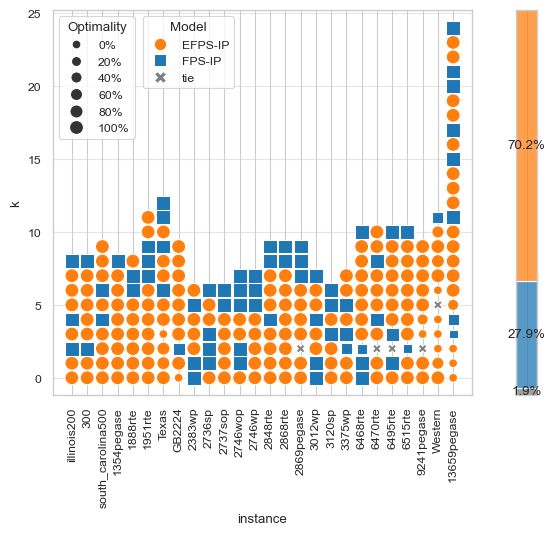

In [12]:
solvers = ["EFPS-IP","FPS-IP"]
show_best_solver(df2, solvers, colors, markers, success=True)

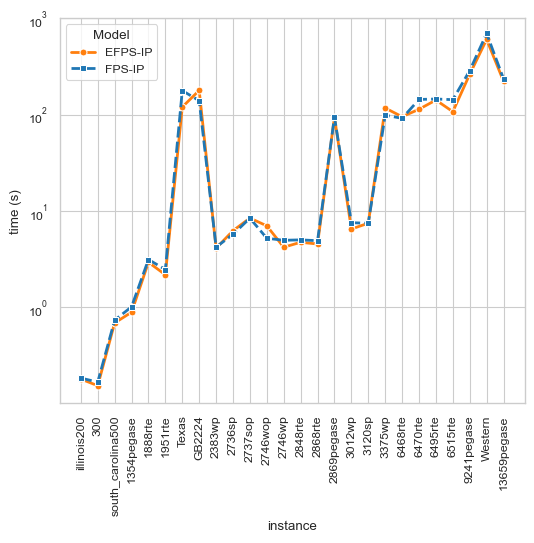

In [13]:
show_execution_time(df, solvers, colors, markers, log_scale=True)

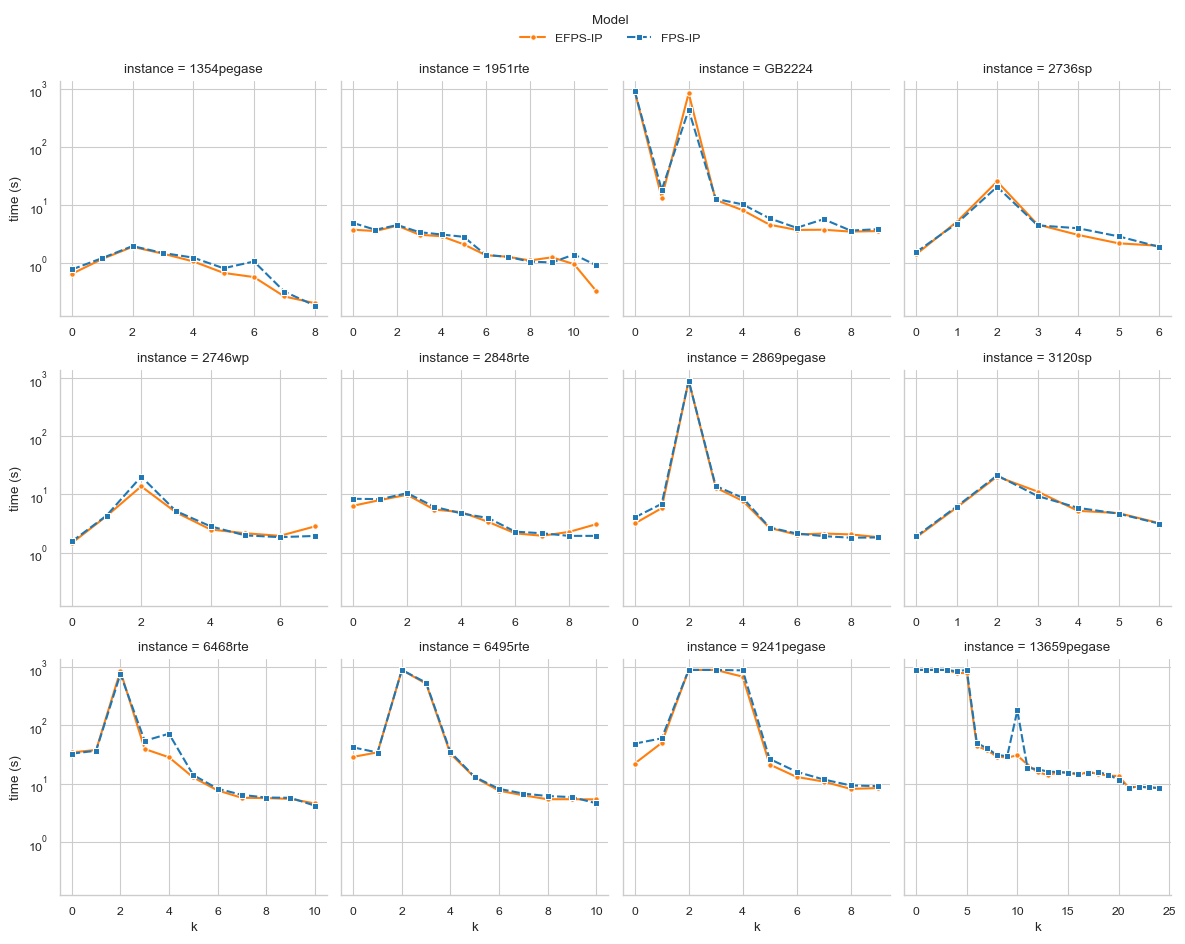

In [14]:
show_execution_time_grid(df, solvers, colors, markers, 12, 4, legend_xpos=0.45, log_scale=True, sharey=True)

## EFPS-IP: InP and OutP

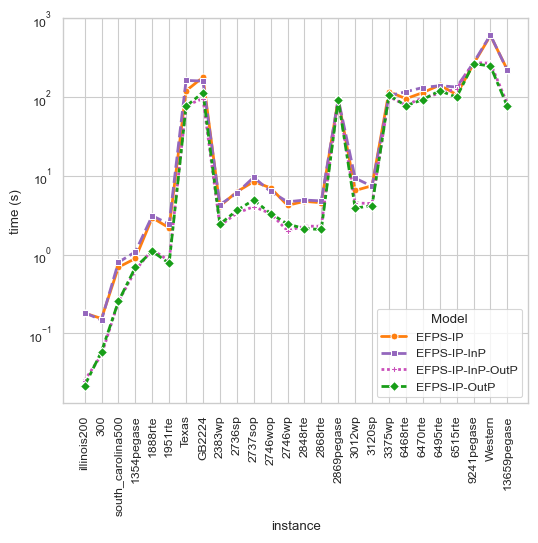

In [15]:
solvers = ["EFPS-IP", "EFPS-IP-InP", "EFPS-IP-InP-OutP", "EFPS-IP-OutP"]
show_execution_time(df, solvers, colors, markers, log_scale=True)

## EFPS-IP: Init

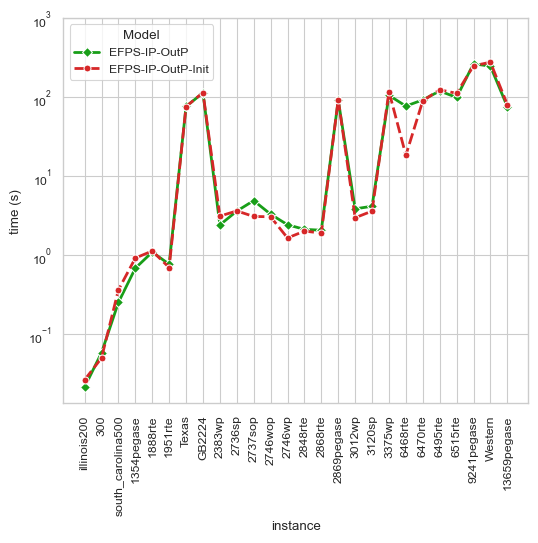

In [16]:
solvers = ["EFPS-IP-OutP", "EFPS-IP-OutP-Init"]
show_execution_time(df, solvers, colors, markers, log_scale=True)

## BRI-IP vs. JOV-IP vs. FORT-IP vs. EFPS-IP

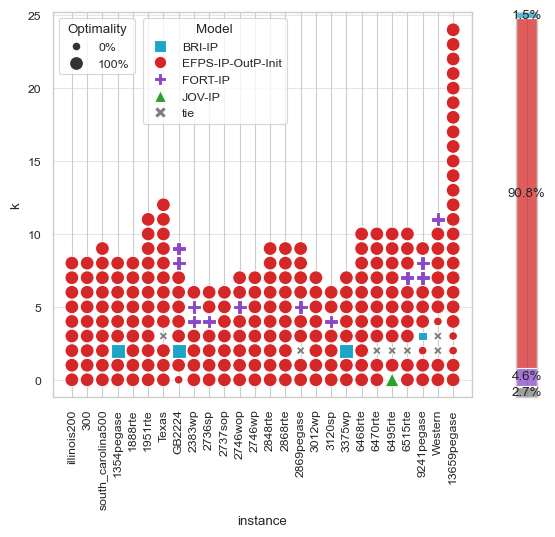

In [17]:
solvers = ["BRI-IP", "EFPS-IP-OutP-Init", "FORT-IP", "JOV-IP"]
show_best_solver(df2, solvers, colors, markers, success=True)

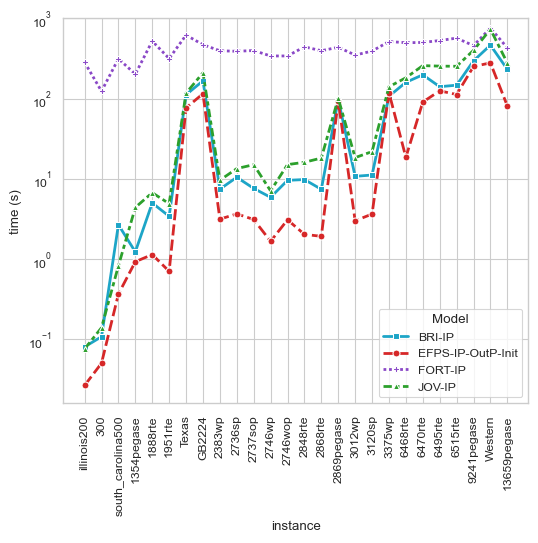

In [18]:
show_execution_time(df, solvers, colors, markers, log_scale=True)

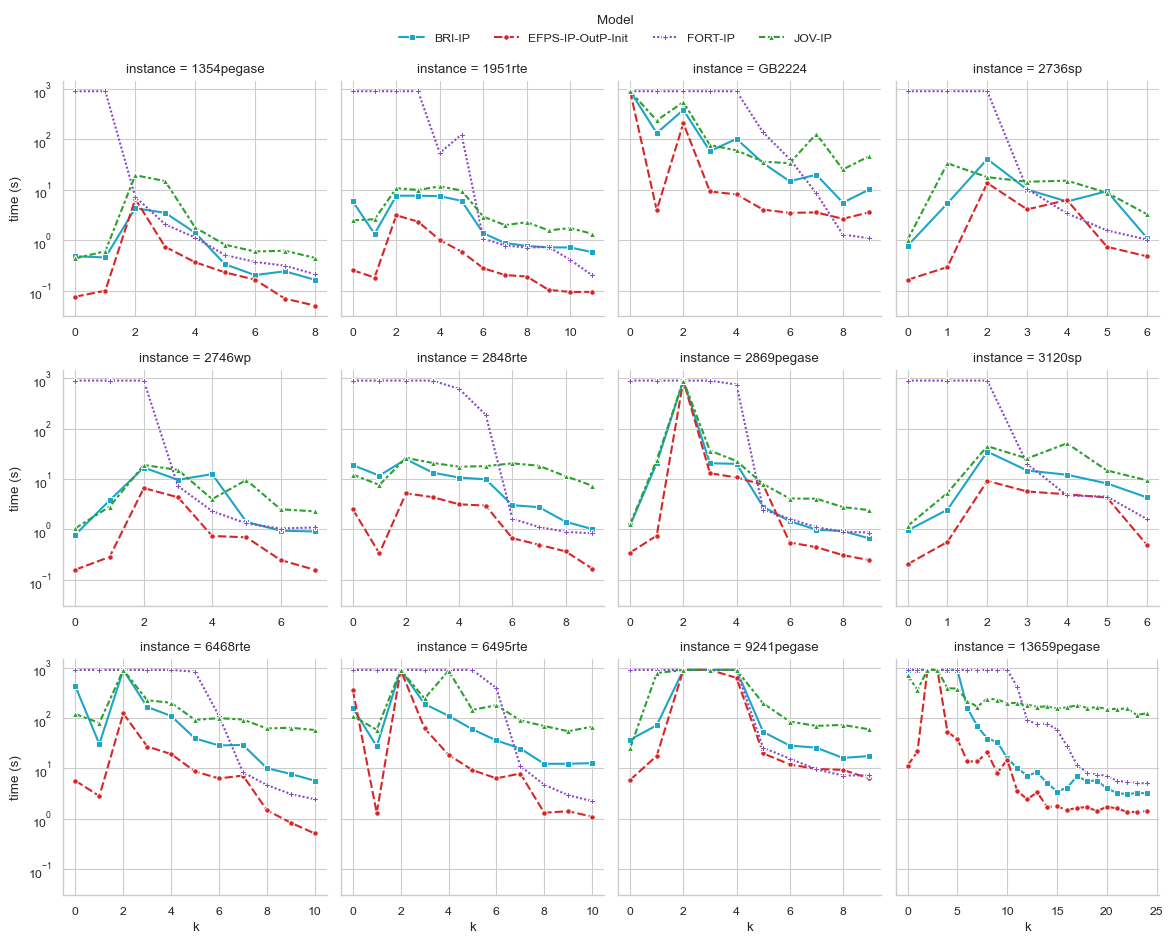

In [19]:
show_execution_time_grid(df, solvers, colors, markers, 12, 4, legend_xpos=0.39, log_scale=True)

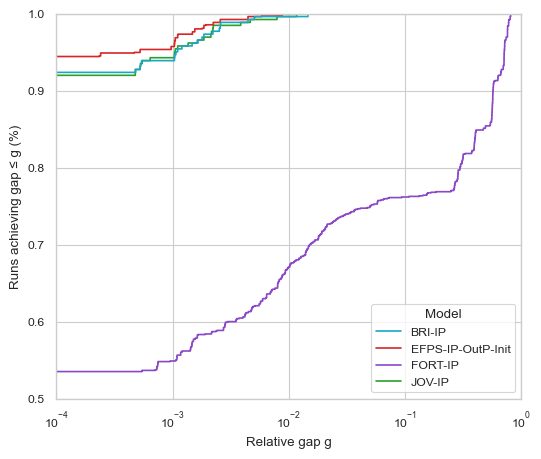

In [20]:
# Replace gap 0 by a very small value for log scale
df.loc[df.gap == 0, "gap"] = 10e-6
show_cumulative_gap(df, solvers, colors, log_scale=True, xlim=(10e-5,1.0), ylim=(0.50,1.0))

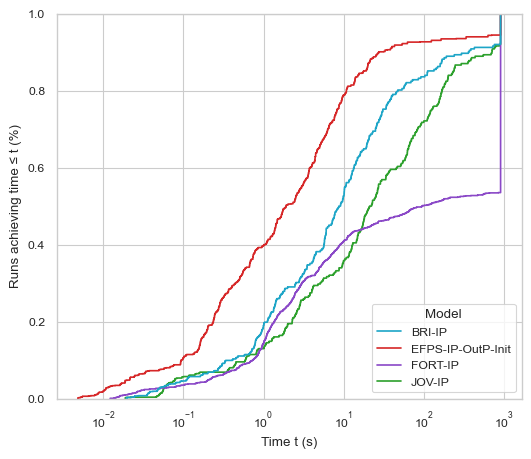

In [21]:
show_cumulative_time(df, solvers, colors, log_scale=True)